Running open-system periodic double-well simulations

Periodic interval:
  X_MIN = -2.0
  X_MAX = 2.0
  GRID_POINTS = 1600
  grid points per well = 800

Well centers:
  0: W0 (center -1.00)
  1: W1 (center 1.00)

Flea specs:
  center=0.820, half_width=0.180, height=0.06000

hbar = 0.2
----------------------------------------------------------------------
Unperturbed low eigenvalues:
  H0 state 0: E = 0.2831693823
  H0 state 1: E = 0.2905173776
  H0 state 2: E = 0.7467662301
  H0 state 3: E = 0.8433915373
  H0 state 4: E = 1.0568440981
  H0 state 5: E = 1.4068535300
  H0 state 6: E = 1.4504677222
  H0 state 7: E = 2.0988103083
Flea Hamiltonian low eigenvalues:
  HF state 0: E = 0.2846058335
  HF state 1: E = 0.2929702748
  HF state 2: E = 0.7473398813
  HF state 3: E = 0.8442763074
  HF state 4: E = 1.0571329488
  HF state 5: E = 1.4071819791
  HF state 6: E = 1.4513817184
  HF state 7: E = 2.1000900976

Symmetric projection norm of raw H0 ground state = 1.00000000
Exact unperturbed ini

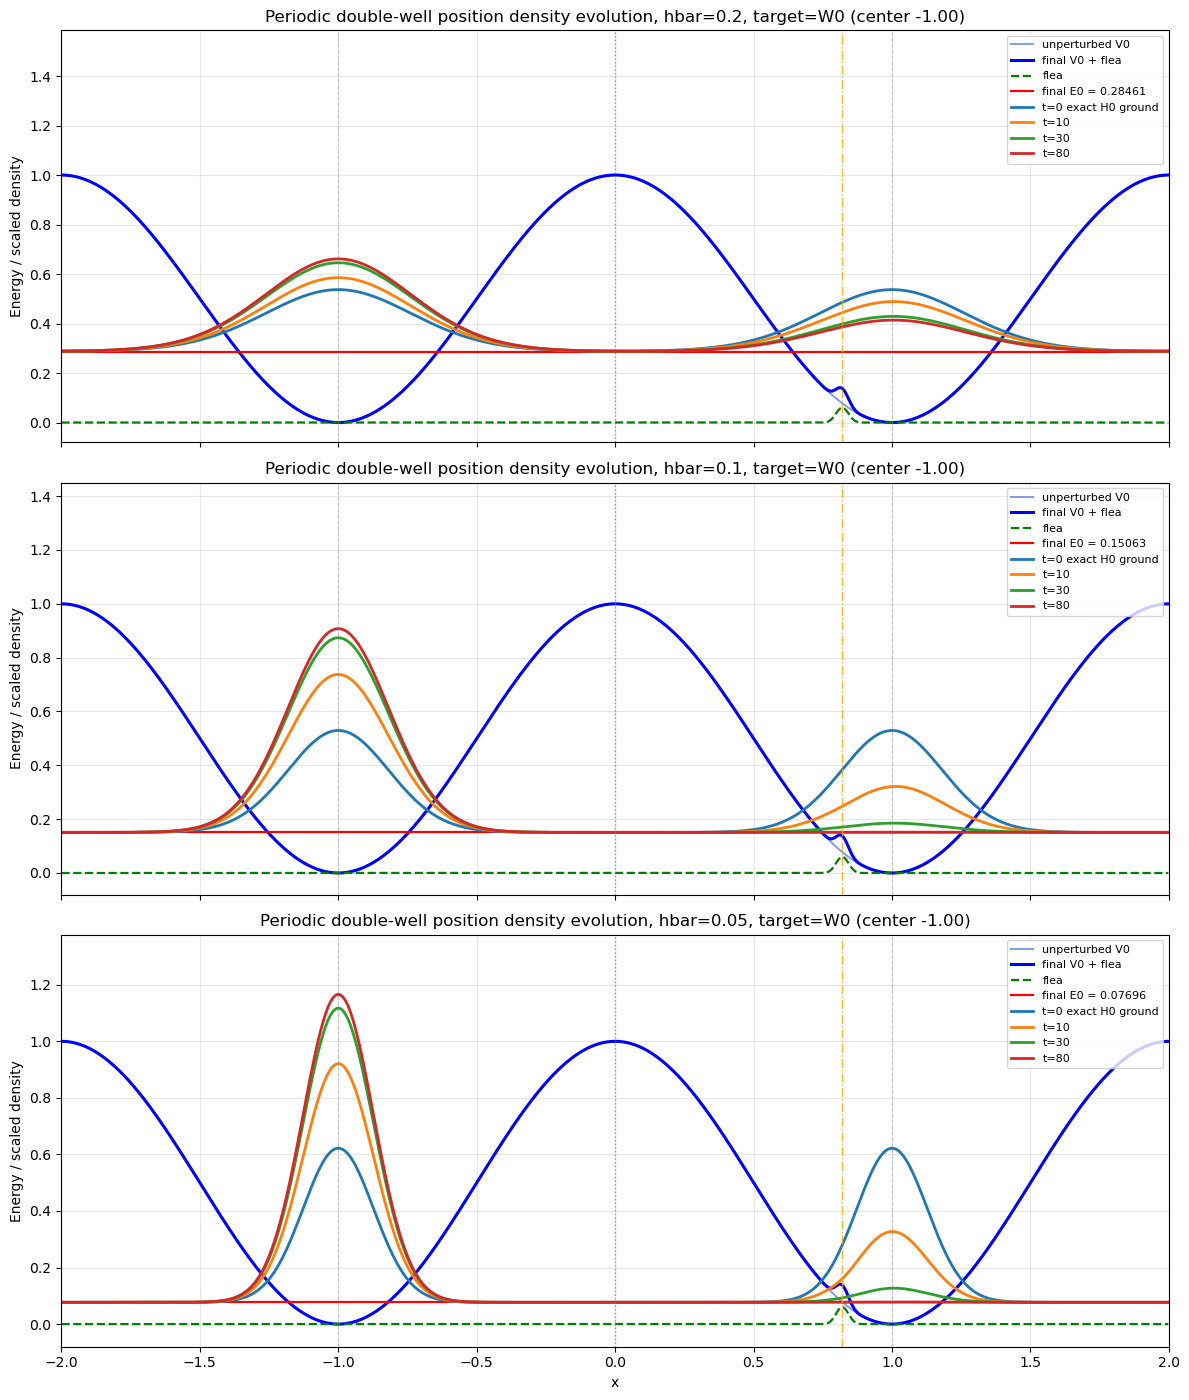

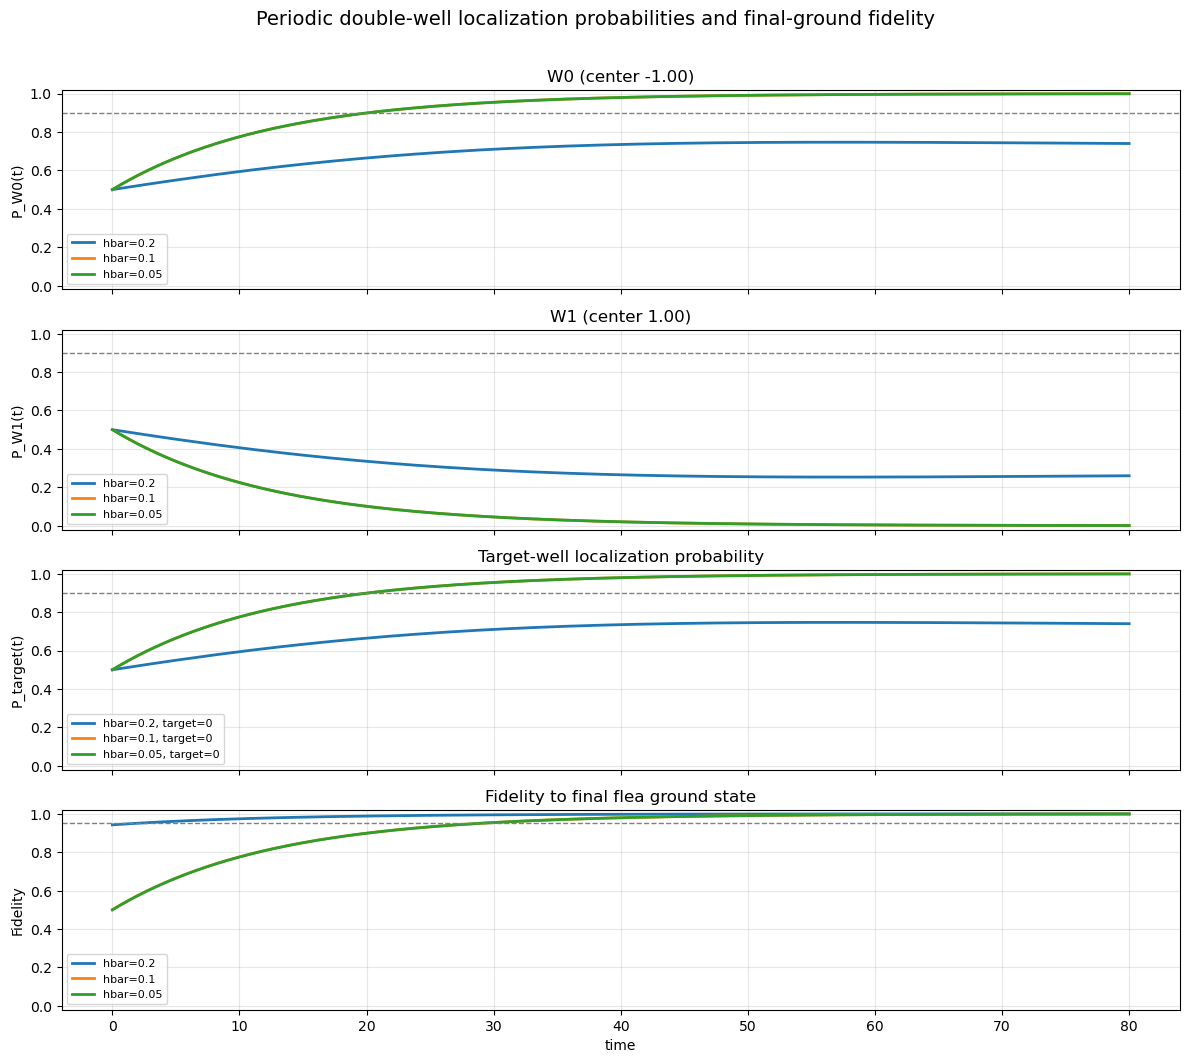

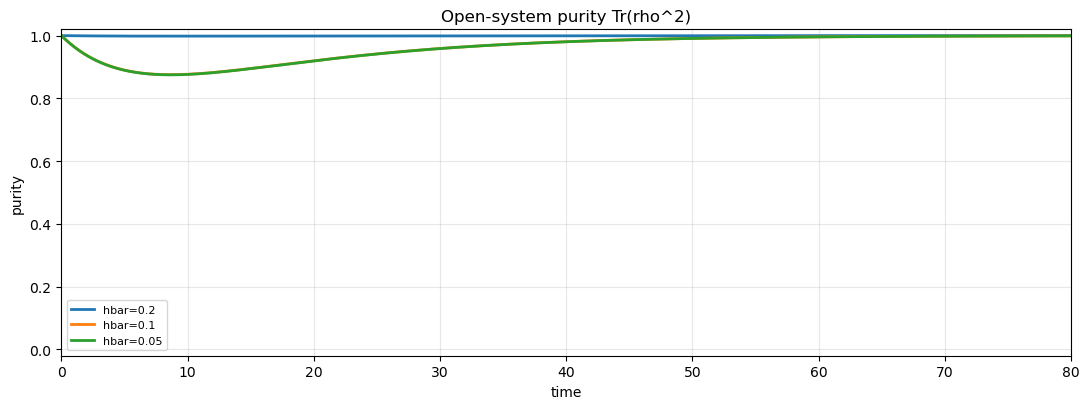

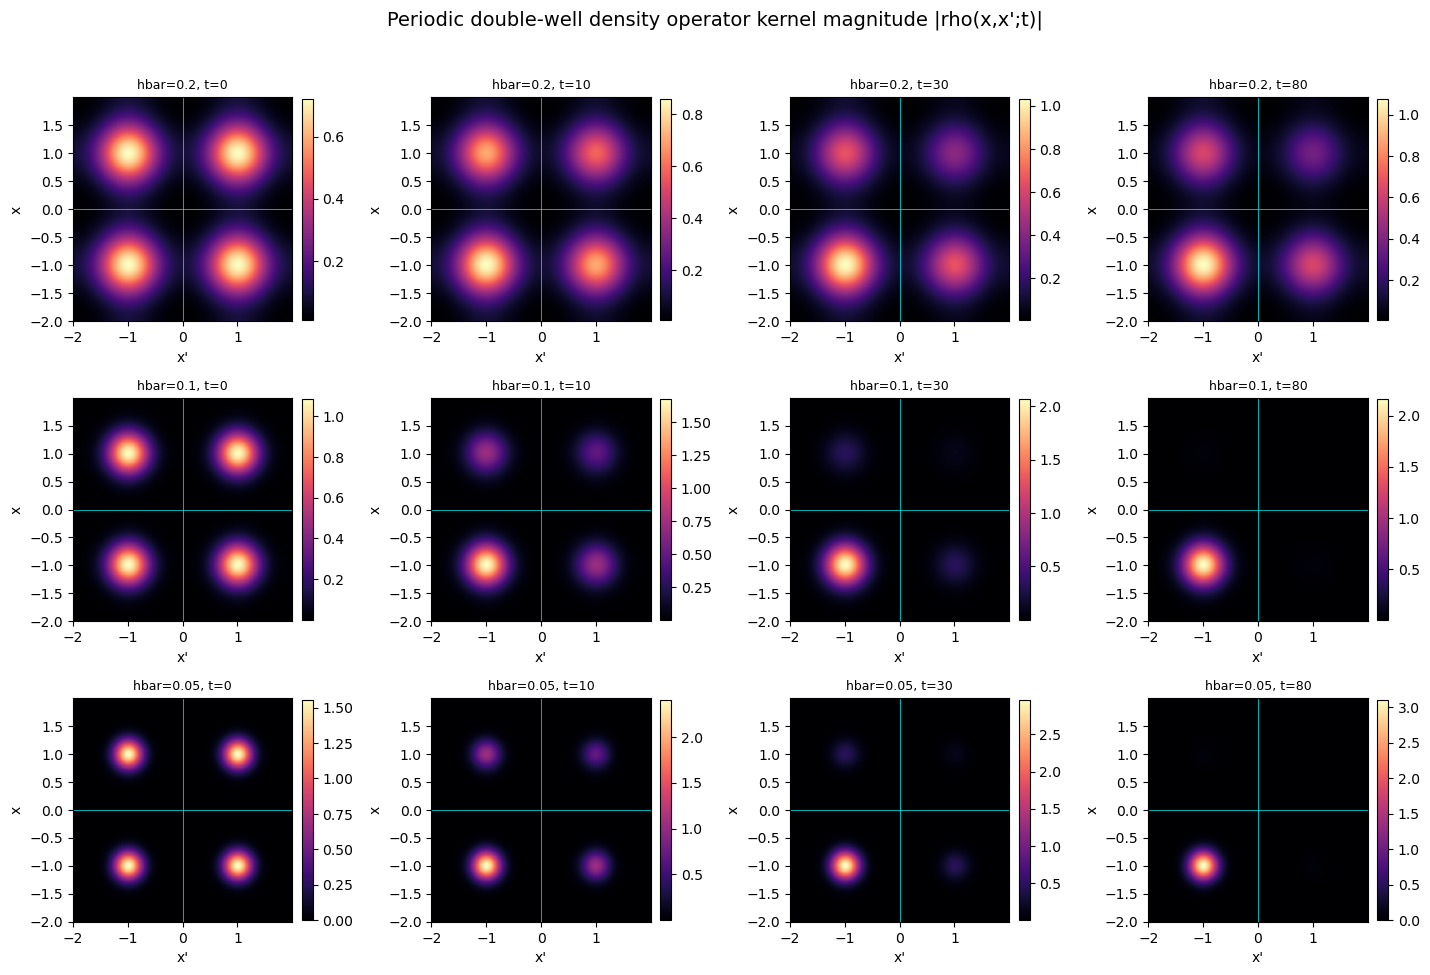


Summary

hbar = 0.2
target well = 0 : W0 (center -1.00)
initial unperturbed well probabilities:
  W0 (center -1.00): 0.500000
  W1 (center 1.00): 0.500000
final ground-state well probabilities:
  W0 (center -1.00): 0.731811
  W1 (center 1.00): 0.268189
symmetry projection norm = 1.000000
projection norm in final basis = 1.000000
final P_target = 0.731811
t_loc_first      = None
t_loc_persistent = None
t_fid_first      = 1.7797552836484984
t_fid_persistent = 1.7797552836484984

hbar = 0.1
target well = 0 : W0 (center -1.00)
initial unperturbed well probabilities:
  W0 (center -1.00): 0.500000
  W1 (center 1.00): 0.500000
final ground-state well probabilities:
  W0 (center -1.00): 0.999997
  W1 (center 1.00): 0.000003
symmetry projection norm = 1.000000
projection norm in final basis = 1.000000
final P_target = 0.999997
t_loc_first      = 20.200222469410456
t_loc_persistent = 20.200222469410456
t_fid_first      = 28.832035595105673
t_fid_persistent = 28.832035595105673

hbar = 0.05
targ

In [1]:
# ============================================================
# Open-system periodic double-well simulation:
# instantaneous flea + relaxation Lindblad dynamics
#
# Periodic compact-interval double-well potential:
#
#     V0(x) = V_B cos^2(pi x / (2a))
#
# on the periodic interval [-2a, 2a), giving two equivalent
# minima near:
#
#     x = -a, a
#
# A positive flea in one well raises that well. With the
# defaults, the flea is placed in the right well near x = +a,
# so the final ground state should localize in the left well
# for sufficiently small hbar.
#
# Master equation:
#
#   d rho / dt = -i/hbar [H_F, rho]
#                + sum_n gamma_n (L_n rho L_n^dagger
#                - 1/2 {L_n^dagger L_n, rho})
#
# with:
#
#   L_n = |phi_0^F><phi_n^F|, n > 0
#
# The initial state is the ground state of the unperturbed
# periodic double-well Hamiltonian. The flea is turned on
# instantaneously at t = 0.
#
# We solve dynamics analytically in the eigenbasis of H_F.
# ============================================================


import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import diags
from scipy.sparse.linalg import eigsh


# ============================================================
# 1. USER SETTINGS
# ============================================================

# Three hbar values
HBAR_VALUES = [0.2, 0.1, 0.05]

# Mass.
# MASS = 0.5 gives kinetic term -hbar^2 d^2/dx^2.
MASS = 0.5

# Periodic double-well cos^2 potential parameters.
N_WELLS = 2
WELL_A = 1.0
BARRIER_HEIGHT = 1.0

# Compact periodic interval.
# For N_WELLS = 2, this gives [-2a, 2a).
X_MIN = -N_WELLS * WELL_A
X_MAX =  N_WELLS * WELL_A

# Two minima of cos^2(pi x / (2a)) on [-2a, 2a):
# x = -a, a.
WELL_MINIMA = WELL_A * np.array(
    [-(N_WELLS - 1) + 2 * j for j in range(N_WELLS)],
    dtype=float
)

# Well boundaries are the barriers halfway between minima,
# plus the compact interval endpoints.
#
# For two wells:
#   W0: [-2a, 0)
#   W1: [0, 2a)
WELL_BOUNDARIES = np.concatenate(
    (
        [X_MIN],
        0.5 * (WELL_MINIMA[:-1] + WELL_MINIMA[1:]),
        [X_MAX]
    )
)

WELL_LABELS = [
    f"W{j} (center {WELL_MINIMA[j]:.2f})"
    for j in range(N_WELLS)
]

# Convenience labels
LEFT_WELL_INDEX = 0
RIGHT_WELL_INDEX = 1

# Grid points.
# For exact discrete twofold symmetry, GRID_POINTS should be
# divisible by N_WELLS.
GRID_POINTS = 1600

# Number of eigenstates used for the truncated open-system basis.
# Increase if the printed "initial-state projection norm" is too small.
N_BASIS = 48

# Number of low eigenvalues to print.
N_PRINT_EIGS = 8

# ------------------------------------------------------------
# Flea parameters.
#
# Positive flea in the right well. The left well is left without
# a flea. With this default, the right well is raised and the
# final ground state should localize in the left well.
#
# To reverse the target well, place the flea in the left well
# instead, e.g. center = -0.82.
# ------------------------------------------------------------

FLEA_SPECS = [
    {"center": 0.82, "half_width": 0.18, "height": 0.060},
]

# Relaxation rate.
# This is the dissipative strength in the final flea eigenbasis.
GAMMA_RELAX = 0.08

# Time settings
T_MAX = 80.0
N_TIME = 900

# Times to show in the density plots and density-matrix heatmaps
PLOT_TIMES = [0.0, 10.0, 30.0, 80.0]

# Localization threshold.
# Absolute threshold: target well probability must exceed this.
LOCALIZATION_THRESHOLD = 0.90

# Fidelity threshold to the final flea ground state
FIDELITY_THRESHOLD = 0.95

# Plot scaling
DENSITY_SCALE = 0.35

# Density matrix heatmap settings
MAKE_DENSITY_MATRIX_HEATMAPS = True
MATRIX_PLOT_POINTS = 170

# Save figures?
SAVE_FIGURES = False


# ============================================================
# 2. POTENTIALS
# ============================================================

def periodic_double_well_cos2_potential(x, a=WELL_A, barrier_height=BARRIER_HEIGHT):
    """
    Symmetric periodic double-well cosine-squared potential.

        V0(x) = barrier_height * cos^2(pi x / (2a))

    With x in [-2a, 2a), this has two equivalent minima near:
        -a, a.
    """
    return barrier_height * np.cos(np.pi * x / (2.0 * a))**2


def smooth_flea_bump(x, center, half_width, height):
    """
    Smooth compactly supported flea perturbation.

    Nonzero only for |x - center| < half_width.

        F(x) = height * exp(1/c^2 - 1/(c^2 - (x-b)^2))
    """
    b = center
    c = half_width
    d = height

    bump = np.zeros_like(x)
    mask = np.abs(x - b) < c

    bump[mask] = d * np.exp(
        1.0 / c**2 - 1.0 / (c**2 - (x[mask] - b)**2)
    )

    return bump


def combined_fleas(x, flea_specs=FLEA_SPECS):
    """
    Sum of all flea bumps.

    For this double-well model, the default is one flea.
    """
    total = np.zeros_like(x)

    for spec in flea_specs:
        total += smooth_flea_bump(
            x,
            center=spec["center"],
            half_width=spec["half_width"],
            height=spec["height"]
        )

    return total


def final_flea_potential(x):
    """
    Final potential after instantaneous flea turn-on.
    """
    return periodic_double_well_cos2_potential(x) + combined_fleas(x)


# ============================================================
# 3. GRID AND HAMILTONIAN
#    PERIODIC boundary conditions
# ============================================================

def make_periodic_grid(x_min=X_MIN, x_max=X_MAX, n=GRID_POINTS):
    """
    Periodic grid on [x_min, x_max).

    The endpoint x_max is not included, so x_min and x_max
    are identified as the same point.

    This is essential for the double-well cos^2 potential to have
    exact translation symmetry between the two wells.
    """
    if n % N_WELLS != 0:
        raise ValueError(
            "For exact discrete well symmetry, choose GRID_POINTS "
            "divisible by N_WELLS."
        )

    x = np.linspace(x_min, x_max, n, endpoint=False)
    dx = (x_max - x_min) / n

    return x, dx


def second_derivative_matrix(n, dx):
    """
    Central finite-difference second derivative with periodic
    boundary conditions.

    Stencil:

        psi''(x_j) approx (psi_{j-1} - 2 psi_j + psi_{j+1}) / dx^2

    with wraparound:

        psi_{-1} = psi_{n-1}
        psi_n    = psi_0
    """
    main_diag = -2.0 * np.ones(n)
    off_diag = np.ones(n - 1)

    D2 = diags(
        diagonals=[off_diag, main_diag, off_diag],
        offsets=[-1, 0, 1],
        shape=(n, n),
        format="lil"
    )

    # Periodic wraparound terms
    D2[0, n - 1] = 1.0
    D2[n - 1, 0] = 1.0

    D2 = D2.tocsc() / dx**2

    return D2


def build_hamiltonian(x, dx, hbar, potential_values):
    """
    H = -(hbar^2 / 2m) D2 + V(x)
    """
    n = len(x)

    D2 = second_derivative_matrix(n, dx)

    kinetic = -(hbar**2 / (2.0 * MASS)) * D2
    potential = diags(potential_values, 0, format="csc")

    H = kinetic + potential
    return H


# ============================================================
# 4. EIGENPROBLEM AND SYMMETRIZATION
# ============================================================

def normalize_wavefunctions(x, psi_matrix):
    """
    Normalize eigenvectors so that integral |psi|^2 dx = 1.
    """
    dx = x[1] - x[0]
    psi = psi_matrix.copy()

    for j in range(psi.shape[1]):
        norm = np.sqrt(np.sum(np.abs(psi[:, j])**2) * dx)
        psi[:, j] = psi[:, j] / norm

        # Fix arbitrary sign for plotting
        max_index = np.argmax(np.abs(psi[:, j]))
        if np.real(psi[max_index, j]) < 0:
            psi[:, j] *= -1

    return psi


def normalize_single_wavefunction(x, psi):
    """
    Normalize one wavefunction so that integral |psi|^2 dx = 1.
    """
    dx = x[1] - x[0]
    psi_out = psi.copy()

    norm = np.sqrt(np.sum(np.abs(psi_out)**2) * dx)
    if norm > 0:
        psi_out = psi_out / norm

    # Fix arbitrary sign for plotting
    max_index = np.argmax(np.abs(psi_out))
    if np.real(psi_out[max_index]) < 0:
        psi_out *= -1

    return psi_out, norm


def solve_low_eigenstates(H, x, k=N_BASIS):
    """
    Solve for lowest k eigenvalues and eigenvectors.
    """
    E, psi = eigsh(
        H,
        k=k,
        which="SA",
        tol=1e-11,
        maxiter=600000
    )

    idx = np.argsort(E)
    E = E[idx]
    psi = psi[:, idx]

    psi = normalize_wavefunctions(x, psi)

    return E, psi


def translation_symmetrize_wavefunction(x, psi, n_wells=N_WELLS):
    """
    Project a wavefunction onto the translation-invariant sector
    of the periodic double-well ring.

    For the double well, translation by one well corresponds to
    rolling the grid by len(x) / 2 points.

    The true unperturbed ground state of the periodic symmetric
    double-well model is translation invariant.
    """
    n = len(x)

    if n % n_wells != 0:
        raise ValueError("Grid size must be divisible by n_wells.")

    shift = n // n_wells

    psi_sym = np.zeros_like(psi, dtype=complex)

    for r in range(n_wells):
        psi_sym += np.roll(psi, r * shift)

    psi_sym = psi_sym / n_wells

    psi_sym, sym_projection_norm = normalize_single_wavefunction(x, psi_sym)

    return psi_sym, sym_projection_norm


# ============================================================
# 5. MASTER EQUATION SOLUTION IN FINAL ENERGY BASIS
# ============================================================

def initial_state_in_final_basis(x, psi_initial, phi_final):
    """
    Compute expansion coefficients of the initial wavefunction
    in the final flea eigenbasis.

        c_n = <phi_n^F | psi_initial>

    The inner product is discretized with dx.
    """
    dx = x[1] - x[0]

    c = phi_final.conj().T @ psi_initial * dx

    projection_norm = np.sum(np.abs(c)**2)

    # Renormalize within truncated basis.
    # This keeps trace exactly one in the truncated model.
    if projection_norm > 0:
        c = c / np.sqrt(projection_norm)

    rho0 = np.outer(c, c.conj())

    return c, rho0, projection_norm


def relaxation_rates(E_final, gamma_base=GAMMA_RELAX):
    """
    Simple low-temperature relaxation:
    each excited final eigenstate decays directly to the final ground state.

        L_n = sqrt(gamma_n) |0><n|

    Here we use constant gamma_n for n > 0.
    """
    gamma = np.zeros_like(E_final)
    gamma[1:] = gamma_base
    return gamma


def rho_energy_basis_at_time(t, E_final, c_initial, gamma, hbar):
    """
    Exact solution of the Lindblad equation in final energy basis
    for jumps L_n = sqrt(gamma_n) |0><n|.

    Initial rho_mn(0) = c_m c_n^*.

    For n > 0:
        rho_nn(t) = rho_nn(0) exp(-gamma_n t)

    Ground population:
        rho_00(t) = rho_00(0) + sum_n>0 rho_nn(0)(1-exp(-gamma_n t))

    Off-diagonals:
        rho_mn(t) = rho_mn(0)
                    exp[-i(E_m-E_n)t/hbar]
                    exp[-1/2(gamma_m+gamma_n)t]
    """
    c = c_initial
    n = len(c)

    rho0 = np.outer(c, c.conj())

    rho = np.zeros((n, n), dtype=complex)

    # Off-diagonal and diagonal excited-state evolution
    for m in range(n):
        for k in range(n):
            if m == 0 and k == 0:
                continue

            phase = np.exp(-1j * (E_final[m] - E_final[k]) * t / hbar)
            decay = np.exp(-0.5 * (gamma[m] + gamma[k]) * t)
            rho[m, k] = rho0[m, k] * phase * decay

    # Ground population receives decayed excited populations
    rho[0, 0] = rho0[0, 0].real
    for k in range(1, n):
        rho[0, 0] += rho0[k, k].real * (1.0 - np.exp(-gamma[k] * t))

    # Small numerical cleanup
    rho = 0.5 * (rho + rho.conj().T)
    rho = rho / np.trace(rho).real

    return rho


# ============================================================
# 6. POSITION-SPACE OBSERVABLES
# ============================================================

def well_mask(x, well_index):
    """
    Return grid mask for one of the two wells.

    Wells are partitioned by WELL_BOUNDARIES:

        W0: [boundary0, boundary1) = [X_MIN, 0)
        W1: [boundary1, boundary2) = [0, X_MAX)

    Since the grid is periodic and endpoint=False, x = X_MAX
    is not included.
    """
    left = WELL_BOUNDARIES[well_index]
    right = WELL_BOUNDARIES[well_index + 1]

    mask = (x >= left) & (x < right)

    return mask


def well_projector_matrix(x, phi_final, well_index):
    """
    Matrix representation of a well-region projector
    in the final eigenbasis.
    """
    dx = x[1] - x[0]

    mask = well_mask(x, well_index)

    phi_region = phi_final[mask, :]
    P = phi_region.conj().T @ phi_region * dx

    return P


def all_well_projector_matrices(x, phi_final):
    """
    Return list of projector matrices, one for each well.
    """
    return [
        well_projector_matrix(x, phi_final, j)
        for j in range(N_WELLS)
    ]


def exact_well_probabilities_from_wavefunction(x, psi):
    """
    Compute exact well probabilities from a position-space wavefunction.
    """
    dx = x[1] - x[0]

    probs = np.zeros(N_WELLS)

    for j in range(N_WELLS):
        mask = well_mask(x, j)
        probs[j] = np.sum(np.abs(psi[mask])**2) * dx

    return probs


def probability_from_projector(P, rho):
    """
    Compute Tr(P rho) in the energy basis.
    """
    return np.real(np.trace(P @ rho))


def position_density(x, phi_final, rho):
    """
    Compute rho(x,x;t) from energy-basis rho.

        density(x) = sum_mn phi_m(x) rho_mn phi_n^*(x)
    """
    density = np.einsum(
        "xm,mn,xn->x",
        phi_final,
        rho,
        phi_final.conj(),
        optimize=True
    )

    density = np.real(density)

    # Remove tiny numerical negatives
    density[density < 0] = np.maximum(density[density < 0], -1e-12)
    density = np.maximum(density, 0.0)

    return density


def density_matrix_kernel_downsampled(x, phi_final, rho, n_points=MATRIX_PLOT_POINTS):
    """
    Compute downsampled position-space density matrix kernel:

        rho(x,x') = sum_mn phi_m(x) rho_mn phi_n^*(x')
    """
    idx = np.linspace(0, len(x) - 1, n_points).astype(int)
    x_small = x[idx]
    phi_small = phi_final[idx, :]

    kernel = phi_small @ rho @ phi_small.conj().T

    return x_small, kernel


def purity(rho):
    """
    Purity Tr(rho^2).
    """
    return np.real(np.trace(rho @ rho))


def fidelity_to_final_ground(rho):
    """
    In the final flea energy basis, final ground state is |0>.
    Fidelity with |0><0| is rho_00.
    """
    return np.real(rho[0, 0])


# ============================================================
# 7. LOCALIZATION TIME ESTIMATES
# ============================================================

def first_persistent_crossing(time_grid, values, threshold):
    """
    Return first time where values stay above threshold
    for all later sampled times.

    If never reached, return None.
    """
    above = values >= threshold

    for i in range(len(time_grid)):
        if np.all(above[i:]):
            return time_grid[i]

    return None


def first_crossing(time_grid, values, threshold):
    """
    Return first time where values exceed threshold.
    If never reached, return None.
    """
    idx = np.where(values >= threshold)[0]
    if len(idx) == 0:
        return None
    return time_grid[idx[0]]


# ============================================================
# 8. RUN ONE HBAR VALUE
# ============================================================

def run_one_hbar(hbar):
    """
    Full pipeline for one value of hbar:
    1. solve unperturbed ground state
    2. symmetrize the unperturbed ground state under well translations
    3. solve final flea eigenbasis
    4. project initial state into final basis
    5. evolve open-system master equation
    6. compute localization observables
    """
    x, dx = make_periodic_grid()

    V0 = periodic_double_well_cos2_potential(x)
    VF = combined_fleas(x)
    V_final = V0 + VF

    H0 = build_hamiltonian(x, dx, hbar, V0)
    HF = build_hamiltonian(x, dx, hbar, V_final)

    # Need at least one eigenstate for H0, but compute more for diagnostics.
    k_initial = min(max(8, N_PRINT_EIGS), N_BASIS)
    E0_unpert, psi_unpert = solve_low_eigenstates(H0, x, k=k_initial)

    # Raw numerical ground state from eigsh
    psi_initial_raw = psi_unpert[:, 0]

    # Symmetrized unperturbed ground state.
    # This corrects possible arbitrary mixtures in the nearly degenerate
    # low-energy doublet and enforces the exact two-well ring symmetry.
    psi_initial, sym_projection_norm = translation_symmetrize_wavefunction(
        x,
        psi_initial_raw,
        n_wells=N_WELLS
    )

    initial_density_exact = np.abs(psi_initial)**2

    initial_P_wells_exact = exact_well_probabilities_from_wavefunction(
        x,
        psi_initial
    )

    E_final, phi_final = solve_low_eigenstates(HF, x, k=N_BASIS)

    c_initial, rho_initial_final_basis, projection_norm = initial_state_in_final_basis(
        x,
        psi_initial,
        phi_final
    )

    initial_density_projected = position_density(
        x,
        phi_final,
        rho_initial_final_basis
    )

    gamma = relaxation_rates(E_final)

    P_well_matrices = all_well_projector_matrices(x, phi_final)

    # Determine target well from final flea ground state
    final_ground_rho = np.zeros((N_BASIS, N_BASIS), dtype=complex)
    final_ground_rho[0, 0] = 1.0

    final_P_wells = np.array([
        probability_from_projector(P, final_ground_rho)
        for P in P_well_matrices
    ])

    target_well_index = int(np.argmax(final_P_wells))
    target_well_label = WELL_LABELS[target_well_index]
    P_target_matrix = P_well_matrices[target_well_index]
    final_P_target = final_P_wells[target_well_index]

    time_grid = np.linspace(0.0, T_MAX, N_TIME)

    P_well_series = np.zeros((len(time_grid), N_WELLS))
    P_target_series = np.zeros_like(time_grid)
    fidelity_series = np.zeros_like(time_grid)
    purity_series = np.zeros_like(time_grid)

    for i, t in enumerate(time_grid):
        rho_t = rho_energy_basis_at_time(
            t,
            E_final,
            c_initial,
            gamma,
            hbar
        )

        for j, Pj in enumerate(P_well_matrices):
            P_well_series[i, j] = probability_from_projector(Pj, rho_t)

        P_target_series[i] = probability_from_projector(P_target_matrix, rho_t)
        fidelity_series[i] = fidelity_to_final_ground(rho_t)
        purity_series[i] = purity(rho_t)

    t_loc_first = first_crossing(
        time_grid,
        P_target_series,
        LOCALIZATION_THRESHOLD
    )

    t_loc_persistent = first_persistent_crossing(
        time_grid,
        P_target_series,
        LOCALIZATION_THRESHOLD
    )

    t_fid_first = first_crossing(
        time_grid,
        fidelity_series,
        FIDELITY_THRESHOLD
    )

    t_fid_persistent = first_persistent_crossing(
        time_grid,
        fidelity_series,
        FIDELITY_THRESHOLD
    )

    return {
        "hbar": hbar,
        "x": x,
        "dx": dx,
        "V0": V0,
        "VF": VF,
        "V_final": V_final,
        "E_unpert": E0_unpert,
        "psi_unpert_low": psi_unpert,
        "psi_initial_raw": psi_initial_raw,
        "psi_initial": psi_initial,
        "sym_projection_norm": sym_projection_norm,
        "initial_density_exact": initial_density_exact,
        "initial_density_projected": initial_density_projected,
        "initial_P_wells_exact": initial_P_wells_exact,
        "E_final": E_final,
        "phi_final": phi_final,
        "c_initial": c_initial,
        "rho_initial_final_basis": rho_initial_final_basis,
        "projection_norm": projection_norm,
        "gamma": gamma,
        "P_well_matrices": P_well_matrices,
        "target_well_index": target_well_index,
        "target_well_label": target_well_label,
        "P_target_matrix": P_target_matrix,
        "final_P_wells": final_P_wells,
        "final_P_target": final_P_target,
        "time_grid": time_grid,
        "P_well_series": P_well_series,
        "P_target_series": P_target_series,
        "fidelity_series": fidelity_series,
        "purity_series": purity_series,
        "t_loc_first": t_loc_first,
        "t_loc_persistent": t_loc_persistent,
        "t_fid_first": t_fid_first,
        "t_fid_persistent": t_fid_persistent
    }


# ============================================================
# 9. RUN ALL HBAR VALUES
# ============================================================

results = []

print("Running open-system periodic double-well simulations")
print("====================================================")
print()
print("Periodic interval:")
print(f"  X_MIN = {X_MIN}")
print(f"  X_MAX = {X_MAX}")
print(f"  GRID_POINTS = {GRID_POINTS}")
print(f"  grid points per well = {GRID_POINTS // N_WELLS}")

print()
print("Well centers:")
for j, label in enumerate(WELL_LABELS):
    print(f"  {j}: {label}")

print()
print("Flea specs:")
for spec in FLEA_SPECS:
    print(
        f"  center={spec['center']:.3f}, "
        f"half_width={spec['half_width']:.3f}, "
        f"height={spec['height']:.5f}"
    )

for hbar in HBAR_VALUES:
    result = run_one_hbar(hbar)
    results.append(result)

    print()
    print(f"hbar = {hbar}")
    print("-" * 70)

    print("Unperturbed low eigenvalues:")
    for n in range(min(N_PRINT_EIGS, len(result["E_unpert"]))):
        print(f"  H0 state {n}: E = {result['E_unpert'][n]:.10f}")

    print("Flea Hamiltonian low eigenvalues:")
    for n in range(min(N_PRINT_EIGS, len(result["E_final"]))):
        print(f"  HF state {n}: E = {result['E_final'][n]:.10f}")

    print()
    print(f"Symmetric projection norm of raw H0 ground state = {result['sym_projection_norm']:.8f}")

    if result["sym_projection_norm"] < 1e-6:
        print(
            "WARNING: raw eigenvector had almost no overlap with the "
            "translation-invariant sector. Increase k_initial or check symmetry."
        )

    print("Exact unperturbed initial-state well probabilities:")
    for j in range(N_WELLS):
        print(f"  {WELL_LABELS[j]}: P = {result['initial_P_wells_exact'][j]:.8f}")

    print()
    print(f"Initial-state projection norm in final basis = {result['projection_norm']:.8f}")

    if result["projection_norm"] < 0.995:
        print(
            "WARNING: initial state is not very well represented in the truncated "
            "final flea eigenbasis. Increase N_BASIS."
        )

    print("Final flea ground-state well probabilities:")
    for j in range(N_WELLS):
        print(f"  {WELL_LABELS[j]}: P = {result['final_P_wells'][j]:.8f}")

    print(f"Target localization well = {result['target_well_index']} : {result['target_well_label']}")

    print()
    print(f"First crossing P_target >= {LOCALIZATION_THRESHOLD}: {result['t_loc_first']}")
    print(f"Persistent P_target >= {LOCALIZATION_THRESHOLD}:   {result['t_loc_persistent']}")
    print(f"First crossing fidelity >= {FIDELITY_THRESHOLD}:   {result['t_fid_first']}")
    print(f"Persistent fidelity >= {FIDELITY_THRESHOLD}:       {result['t_fid_persistent']}")


# ============================================================
# 10. PLOT DENSITIES AT SELECTED TIMES
# ============================================================

fig, axes = plt.subplots(
    nrows=len(results),
    ncols=1,
    figsize=(12, 4.7 * len(results)),
    sharex=True
)

if len(results) == 1:
    axes = [axes]

for ax, result in zip(axes, results):
    hbar = result["hbar"]
    x = result["x"]
    V0 = result["V0"]
    VF = result["VF"]
    V_final = result["V_final"]
    E_final = result["E_final"]
    phi_final = result["phi_final"]
    c_initial = result["c_initial"]
    gamma = result["gamma"]

    ax.plot(
        x,
        V0,
        color="royalblue",
        lw=1.4,
        alpha=0.65,
        label="unperturbed V0"
    )

    ax.plot(
        x,
        V_final,
        color="blue",
        lw=2.2,
        label="final V0 + flea"
    )

    ax.plot(
        x,
        VF,
        color="green",
        lw=1.6,
        ls="--",
        label="flea"
    )

    ax.axhline(
        E_final[0],
        color="red",
        lw=1.6,
        label=f"final E0 = {E_final[0]:.5f}"
    )

    for t in PLOT_TIMES:

        if np.isclose(t, 0.0):
            # Plot exact symmetrized unperturbed ground-state density.
            dens_t = result["initial_density_exact"]
            label = "t=0 exact H0 ground"
        else:
            rho_t = rho_energy_basis_at_time(
                t,
                E_final,
                c_initial,
                gamma,
                hbar
            )

            dens_t = position_density(x, phi_final, rho_t)
            label = f"t={t:g}"

        ax.plot(
            x,
            E_final[0] + DENSITY_SCALE * dens_t,
            lw=2.0,
            label=label
        )

    # Mark well boundary and minima
    for boundary in WELL_BOUNDARIES[1:-1]:
        ax.axvline(boundary, color="gray", lw=1.0, ls=":", alpha=0.8)

    for minimum in WELL_MINIMA:
        ax.axvline(minimum, color="gray", lw=0.8, ls="--", alpha=0.35)

    # Mark flea centers
    for spec in FLEA_SPECS:
        ax.axvline(
            spec["center"],
            color="orange",
            lw=1.0,
            ls="-.",
            alpha=0.8
        )

    ax.set_title(
        f"Periodic double-well position density evolution, hbar={hbar}, "
        f"target={result['target_well_label']}"
    )
    ax.set_ylabel("Energy / scaled density")
    ax.set_xlim(X_MIN, X_MAX)

    upper = max(
        V_final.max() + 0.15,
        E_final[0] + 1.3
    )
    ax.set_ylim(-0.08, upper)

    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("x")
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig("open_periodic_double_well_density_evolution.png", dpi=220)

plt.show()


# ============================================================
# 11. PLOT LOCALIZATION OBSERVABLES
# ============================================================

fig, axes = plt.subplots(
    nrows=N_WELLS + 2,
    ncols=1,
    figsize=(12, 2.7 * (N_WELLS + 2)),
    sharex=True
)

# One row for each well probability
for j in range(N_WELLS):
    for result in results:
        hbar = result["hbar"]
        t = result["time_grid"]

        axes[j].plot(
            t,
            result["P_well_series"][:, j],
            lw=2,
            label=f"hbar={hbar}"
        )

    axes[j].axhline(LOCALIZATION_THRESHOLD, color="gray", ls="--", lw=1)
    axes[j].set_ylabel(f"P_W{j}(t)")
    axes[j].set_ylim(-0.02, 1.02)
    axes[j].grid(alpha=0.3)
    axes[j].legend(fontsize=8)
    axes[j].set_title(WELL_LABELS[j])

# Target probability row
target_row = N_WELLS
for result in results:
    hbar = result["hbar"]
    t = result["time_grid"]
    axes[target_row].plot(
        t,
        result["P_target_series"],
        lw=2,
        label=f"hbar={hbar}, target={result['target_well_index']}"
    )

axes[target_row].axhline(LOCALIZATION_THRESHOLD, color="gray", ls="--", lw=1)
axes[target_row].set_ylabel("P_target(t)")
axes[target_row].set_ylim(-0.02, 1.02)
axes[target_row].grid(alpha=0.3)
axes[target_row].legend(fontsize=8)
axes[target_row].set_title("Target-well localization probability")

# Fidelity row
fid_row = N_WELLS + 1
for result in results:
    hbar = result["hbar"]
    t = result["time_grid"]
    axes[fid_row].plot(
        t,
        result["fidelity_series"],
        lw=2,
        label=f"hbar={hbar}"
    )

axes[fid_row].axhline(FIDELITY_THRESHOLD, color="gray", ls="--", lw=1)
axes[fid_row].set_ylabel("Fidelity")
axes[fid_row].set_xlabel("time")
axes[fid_row].set_ylim(-0.02, 1.02)
axes[fid_row].grid(alpha=0.3)
axes[fid_row].legend(fontsize=8)
axes[fid_row].set_title("Fidelity to final flea ground state")

fig.suptitle(
    "Periodic double-well localization probabilities and final-ground fidelity",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

if SAVE_FIGURES:
    plt.savefig("open_periodic_double_well_localization_times.png", dpi=220)

plt.show()


# ============================================================
# 12. PLOT PURITY
# ============================================================

fig, ax = plt.subplots(figsize=(11, 4.2))

for result in results:
    ax.plot(
        result["time_grid"],
        result["purity_series"],
        lw=2,
        label=f"hbar={result['hbar']}"
    )

ax.set_title("Open-system purity Tr(rho^2)")
ax.set_xlabel("time")
ax.set_ylabel("purity")
ax.set_xlim(0, T_MAX)
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig("open_periodic_double_well_purity.png", dpi=220)

plt.show()


# ============================================================
# 13. VISUALIZE DENSITY OPERATORS |rho(x,x')|
# ============================================================

if MAKE_DENSITY_MATRIX_HEATMAPS:

    n_rows = len(results)
    n_cols = len(PLOT_TIMES)

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(3.6 * n_cols, 3.3 * n_rows),
        sharex=False,
        sharey=False
    )

    if n_rows == 1:
        axes = np.array([axes])

    for row, result in enumerate(results):
        hbar = result["hbar"]
        x = result["x"]
        E_final = result["E_final"]
        phi_final = result["phi_final"]
        c_initial = result["c_initial"]
        gamma = result["gamma"]

        for col, t in enumerate(PLOT_TIMES):
            ax = axes[row, col]

            if np.isclose(t, 0.0):
                # Exact initial pure-state kernel from the unperturbed ground state.
                idx = np.linspace(0, len(x) - 1, MATRIX_PLOT_POINTS).astype(int)
                x_small = x[idx]
                psi_small = result["psi_initial"][idx]
                kernel = np.outer(psi_small, psi_small.conj())
            else:
                rho_t = rho_energy_basis_at_time(
                    t,
                    E_final,
                    c_initial,
                    gamma,
                    hbar
                )

                x_small, kernel = density_matrix_kernel_downsampled(
                    x,
                    phi_final,
                    rho_t,
                    n_points=MATRIX_PLOT_POINTS
                )

            abs_kernel = np.abs(kernel)

            im = ax.imshow(
                abs_kernel,
                extent=[x_small[0], x_small[-1], x_small[0], x_small[-1]],
                origin="lower",
                aspect="auto",
                cmap="magma"
            )

            # Well boundary in both coordinates
            for boundary in WELL_BOUNDARIES[1:-1]:
                ax.axvline(boundary, color="cyan", lw=0.7, alpha=0.7)
                ax.axhline(boundary, color="cyan", lw=0.7, alpha=0.7)

            ax.set_title(f"hbar={hbar}, t={t:g}", fontsize=9)
            ax.set_xlabel("x'")
            ax.set_ylabel("x")

            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(
        "Periodic double-well density operator kernel magnitude |rho(x,x';t)|",
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if SAVE_FIGURES:
        plt.savefig("open_periodic_double_well_density_matrix_heatmaps.png", dpi=220)

    plt.show()


# ============================================================
# 14. SUMMARY TABLE
# ============================================================

print()
print("Summary")
print("=======")

for result in results:
    print()
    print(f"hbar = {result['hbar']}")
    print(f"target well = {result['target_well_index']} : {result['target_well_label']}")

    print("initial unperturbed well probabilities:")
    for j in range(N_WELLS):
        print(f"  {WELL_LABELS[j]}: {result['initial_P_wells_exact'][j]:.6f}")

    print("final ground-state well probabilities:")
    for j in range(N_WELLS):
        print(f"  {WELL_LABELS[j]}: {result['final_P_wells'][j]:.6f}")

    print(f"symmetry projection norm = {result['sym_projection_norm']:.6f}")
    print(f"projection norm in final basis = {result['projection_norm']:.6f}")
    print(f"final P_target = {result['final_P_target']:.6f}")
    print(f"t_loc_first      = {result['t_loc_first']}")
    print(f"t_loc_persistent = {result['t_loc_persistent']}")
    print(f"t_fid_first      = {result['t_fid_first']}")
    print(f"t_fid_persistent = {result['t_fid_persistent']}")